In [1]:
data_folder_path="data/survey1_apf.csv"



# EDA

In [2]:
import pandas as pd
df=pd.read_csv(data_folder_path)

In [3]:
df

,Name of organization,Type of business,APF_ Design changes required in the product,APF_ Variety of products,APF_ Offline part programming preparation facility,APF_ Number of existing part families matching the new product design,APF_ Machine flexibility
0,Relaible Bitumen,Manufacturer of Bitumen drums,4.000000,5.000000,4.000000,5.000000,4.000000
1,Ashok Leyland Ltd,Automobile,4.000000,5.000000,4.000000,3.000000,5.000000
2,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.000000,5.000000,5.000000,5.000000,4.000000
3,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.000000,5.000000,4.000000,5.000000,4.000000
4,Bajaj Auto Ltd.,Automobile Ancilliaries,5.000000,4.000000,4.000000,5.000000,3.000000
...,...,...,...,...,...,...,...
101,GKN driveline India Ltd.,Manufacturing,5.000000,5.000000,3.000000,4.000000,4.000000
102,"FET, MRUI",Teaching,4.000000,3.000000,4.000000,2.000000,4.000000
103,NaN,Average,4.165049,4.184466,4.106796,4.126214,4.330097
104,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns = [x.replace("APF_ ", "") for x in df.columns]

In [5]:
df.columns

Index(['Name of organization', 'Type of business',
       'Design changes required in the product', 'Variety of products',
       'Offline part programming preparation facility',
       'Number of existing part families matching the new product design',
       'Machine flexibility'],
      dtype='str')

In [6]:
df

,Name of organization,Type of business,Design changes required in the product,Variety of products,Offline part programming preparation facility,Number of existing part families matching the new product design,Machine flexibility
0,Relaible Bitumen,Manufacturer of Bitumen drums,4.000000,5.000000,4.000000,5.000000,4.000000
1,Ashok Leyland Ltd,Automobile,4.000000,5.000000,4.000000,3.000000,5.000000
2,Super Circle India Pvt. Ltd.,Manufacturer of Vehicle Parts,4.000000,5.000000,5.000000,5.000000,4.000000
3,Mita India Pvt. Ltd.,Manufaturer Of Tractor Parts,4.000000,5.000000,4.000000,5.000000,4.000000
4,Bajaj Auto Ltd.,Automobile Ancilliaries,5.000000,4.000000,4.000000,5.000000,3.000000
...,...,...,...,...,...,...,...
101,GKN driveline India Ltd.,Manufacturing,5.000000,5.000000,3.000000,4.000000,4.000000
102,"FET, MRUI",Teaching,4.000000,3.000000,4.000000,2.000000,4.000000
103,NaN,Average,4.165049,4.184466,4.106796,4.126214,4.330097
104,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# handling missing values
df.isna().sum()

Name of organization                                                3
Type of business                                                    3
Design changes required in the product                              1
Variety of products                                                 1
Offline part programming preparation facility                       1
Number of existing part families matching the new product design    1
Machine flexibility                                                 1
dtype: int64

In [8]:
df[df.isnull()]

,Name of organization,Type of business,Design changes required in the product,Variety of products,Offline part programming preparation facility,Number of existing part families matching the new product design,Machine flexibility
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- complete raw is nan it means it is excel sheet extra raws removed

In [9]:
df.dropna().isnull().sum()

Name of organization                                                0
Type of business                                                    0
Design changes required in the product                              0
Variety of products                                                 0
Offline part programming preparation facility                       0
Number of existing part families matching the new product design    0
Machine flexibility                                                 0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.sample(10)

,Name of organization,Type of business,Design changes required in the product,Variety of products,Offline part programming preparation facility,Number of existing part families matching the new product design,Machine flexibility
29,Puralator India Ltd,Filter & Auto Parts Manufacturer,4.0,4.0,4.0,5.0,4.0
75,JPM Group,Automotive Parts,4.0,5.0,4.0,3.0,5.0
46,Esvee prescision L.T.D,Auto parts,4.0,4.0,4.0,4.0,4.0
83,Minda corporation,Auto parts,5.0,4.0,5.0,4.0,5.0
41,LPS Boassard,Mechanical Parts,3.0,4.0,4.0,5.0,4.0
69,Golden Engineering Co.,Auto Parts Manufacturing,4.0,3.0,4.0,4.0,5.0
44,Mahindra and Mahindra,Automobile Manufacturing,4.0,4.0,3.0,5.0,5.0
26,Sadhu Forging Ltd,Engine Gear & Different Vehicle Gear Mfg,3.0,4.0,5.0,4.0,5.0
71,Aakar Industries P ltd.,Engineering parts and machine manufacturing,4.0,4.0,3.0,3.0,5.0
91,Hindustan Machinery,MachineÂ parts,5.0,4.0,5.0,4.0,4.0


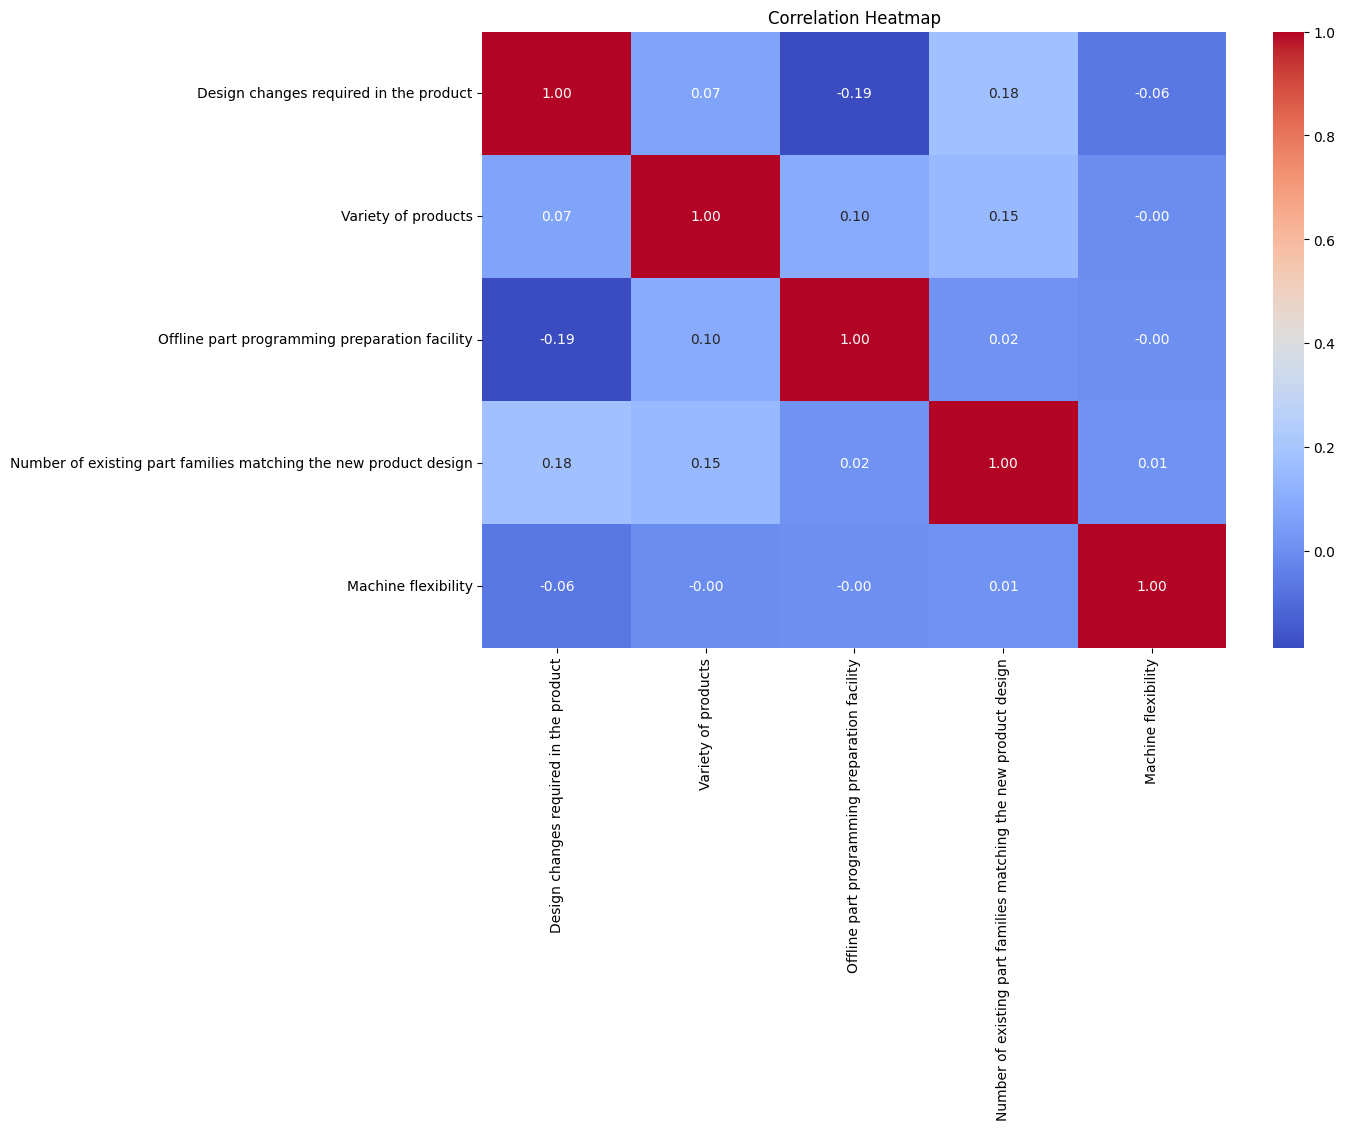

In [12]:
# reolation of other features with other
import matplotlib.pyplot as plt
import seaborn as sns
df_v=df.select_dtypes("float")
plt.figure(figsize=(12,8))
sns.heatmap(df_v.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

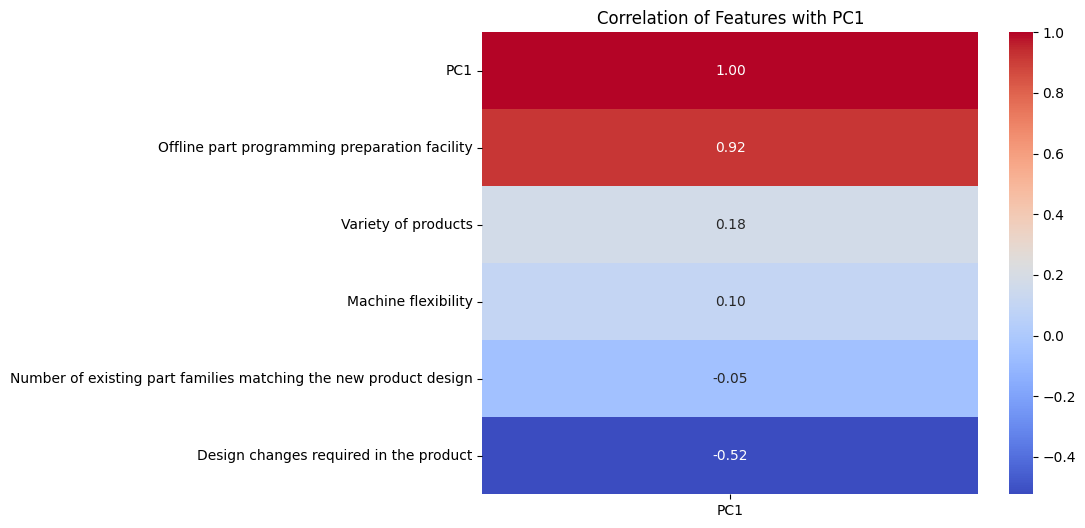

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(numeric_df)

pca = PCA(n_components=1)

pc1 = pca.fit_transform(scaled_data)

numeric_df['PC1'] = pc1

pc1_corr = numeric_df.corr()[['PC1']].sort_values(
    by='PC1',
    ascending=False
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pc1_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation of Features with PC1")

plt.show()

- the feature which has heigh correlation with pc is important most because it contains as much variance of the data set

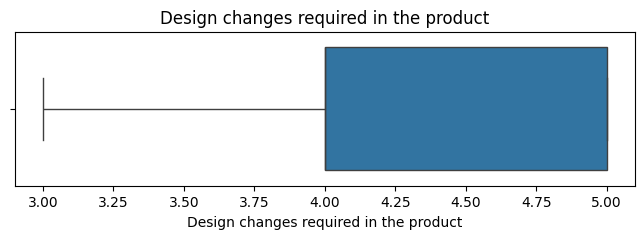

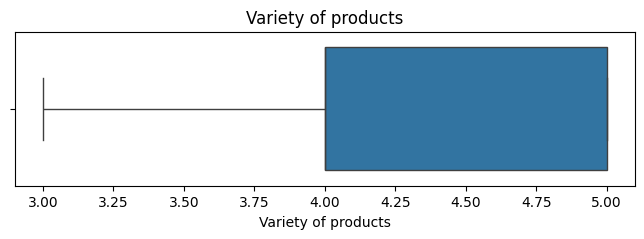

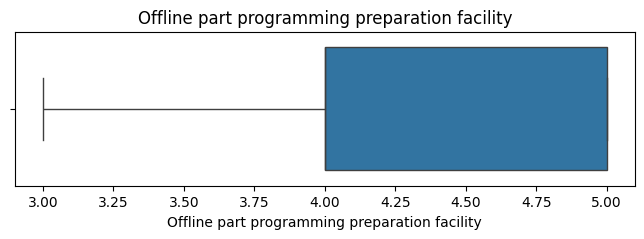

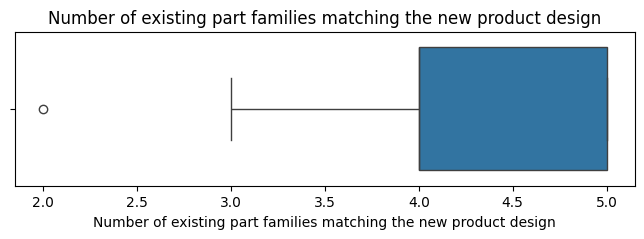

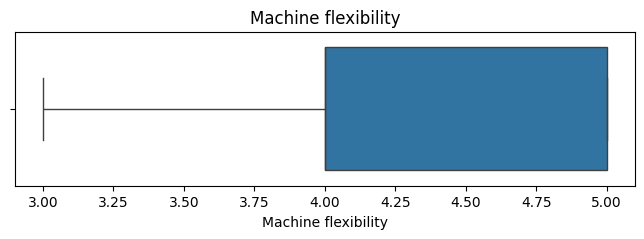

In [14]:
# Looking to the distribution of the dataset


for col in df.select_dtypes(include='float64').columns:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

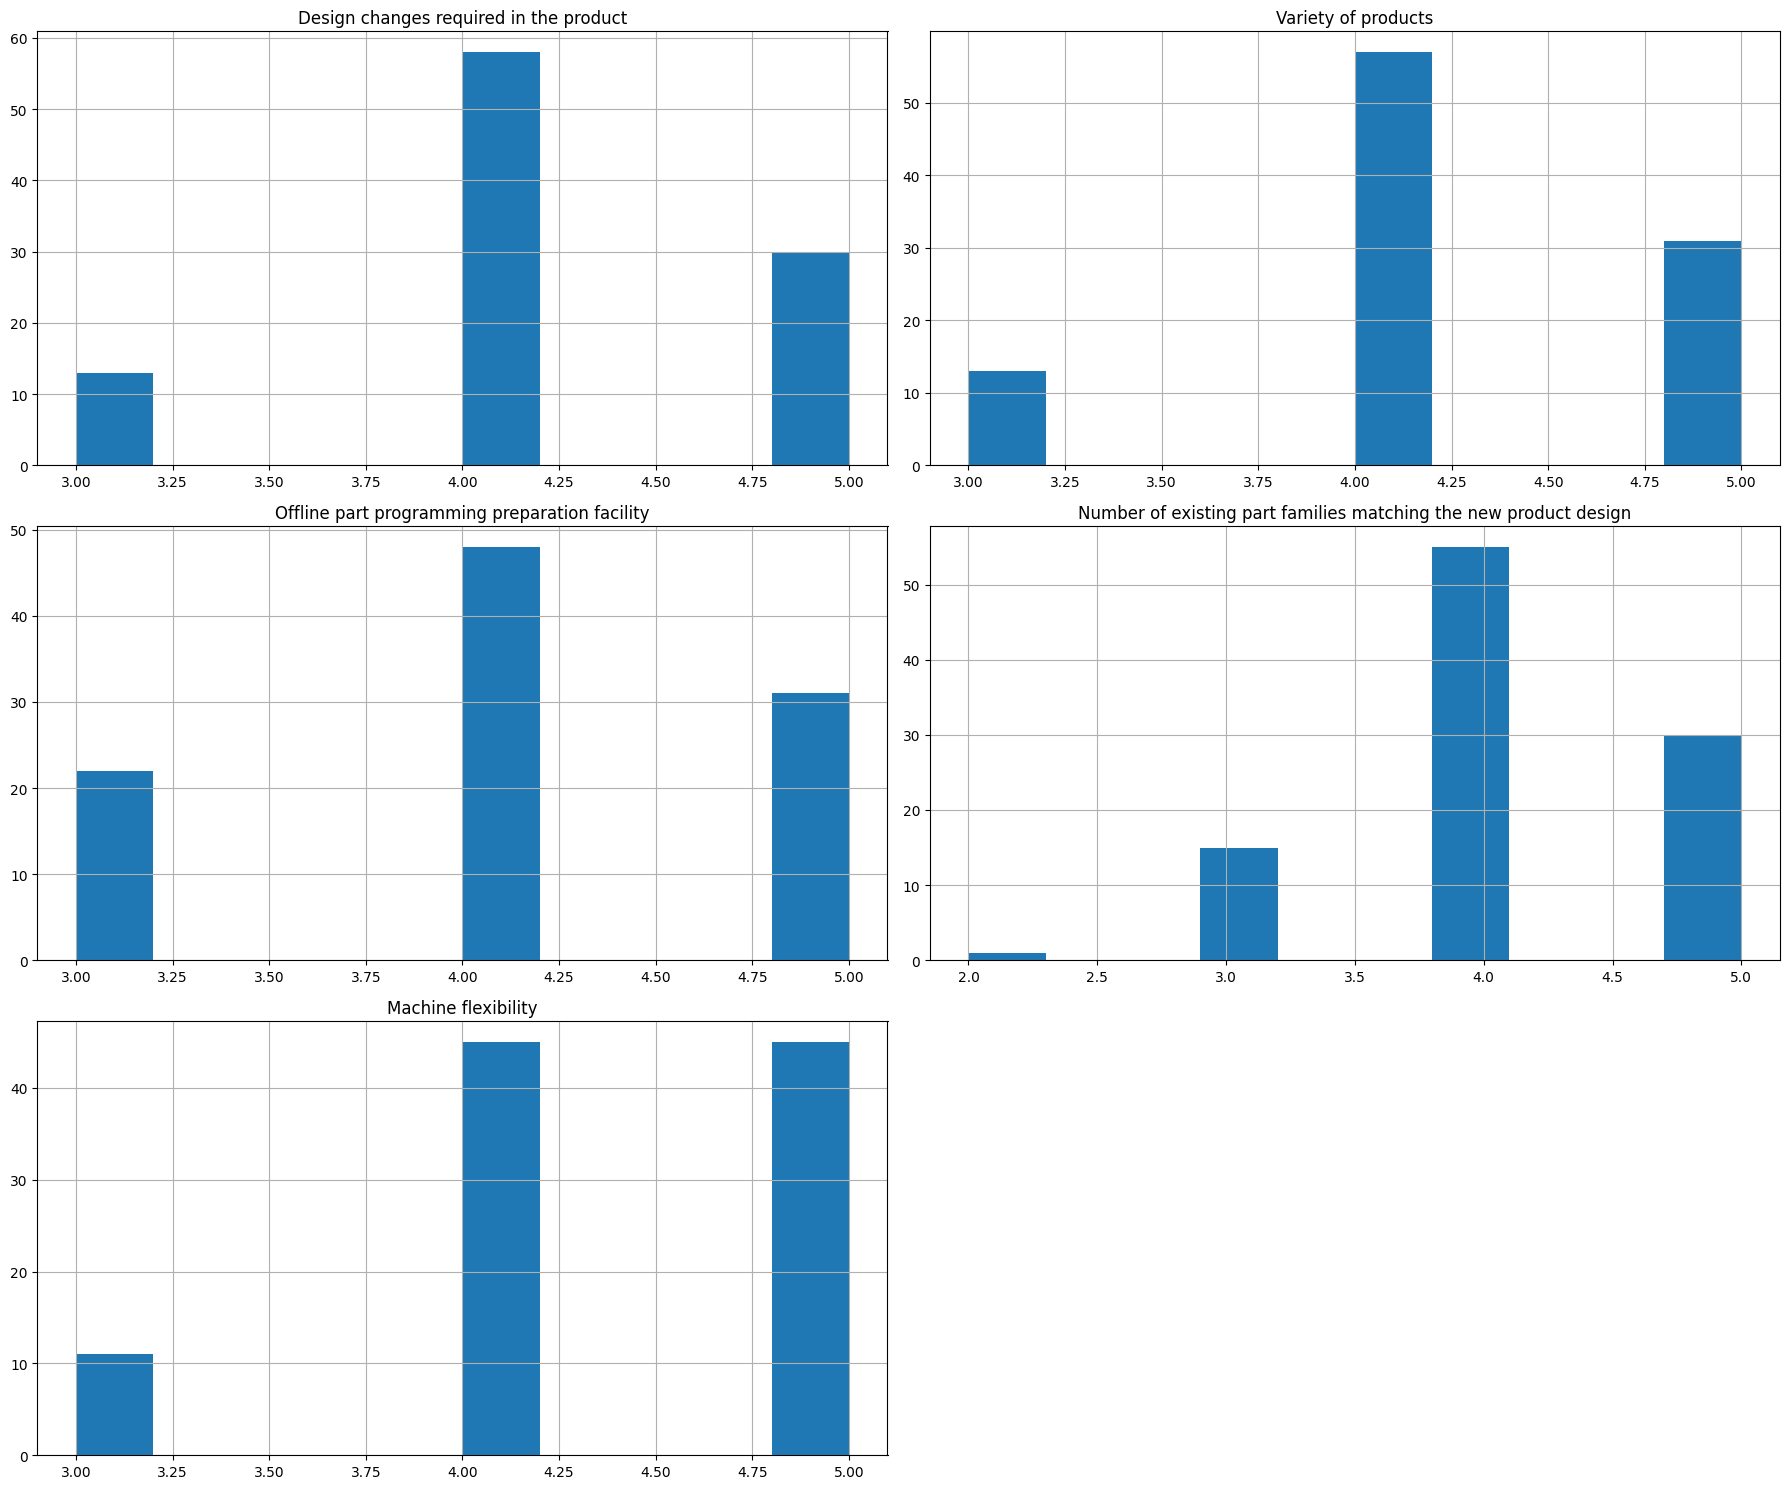

In [15]:
df.hist(figsize=(18,15))
plt.tight_layout()
plt.show()

- this shows how values are distributed

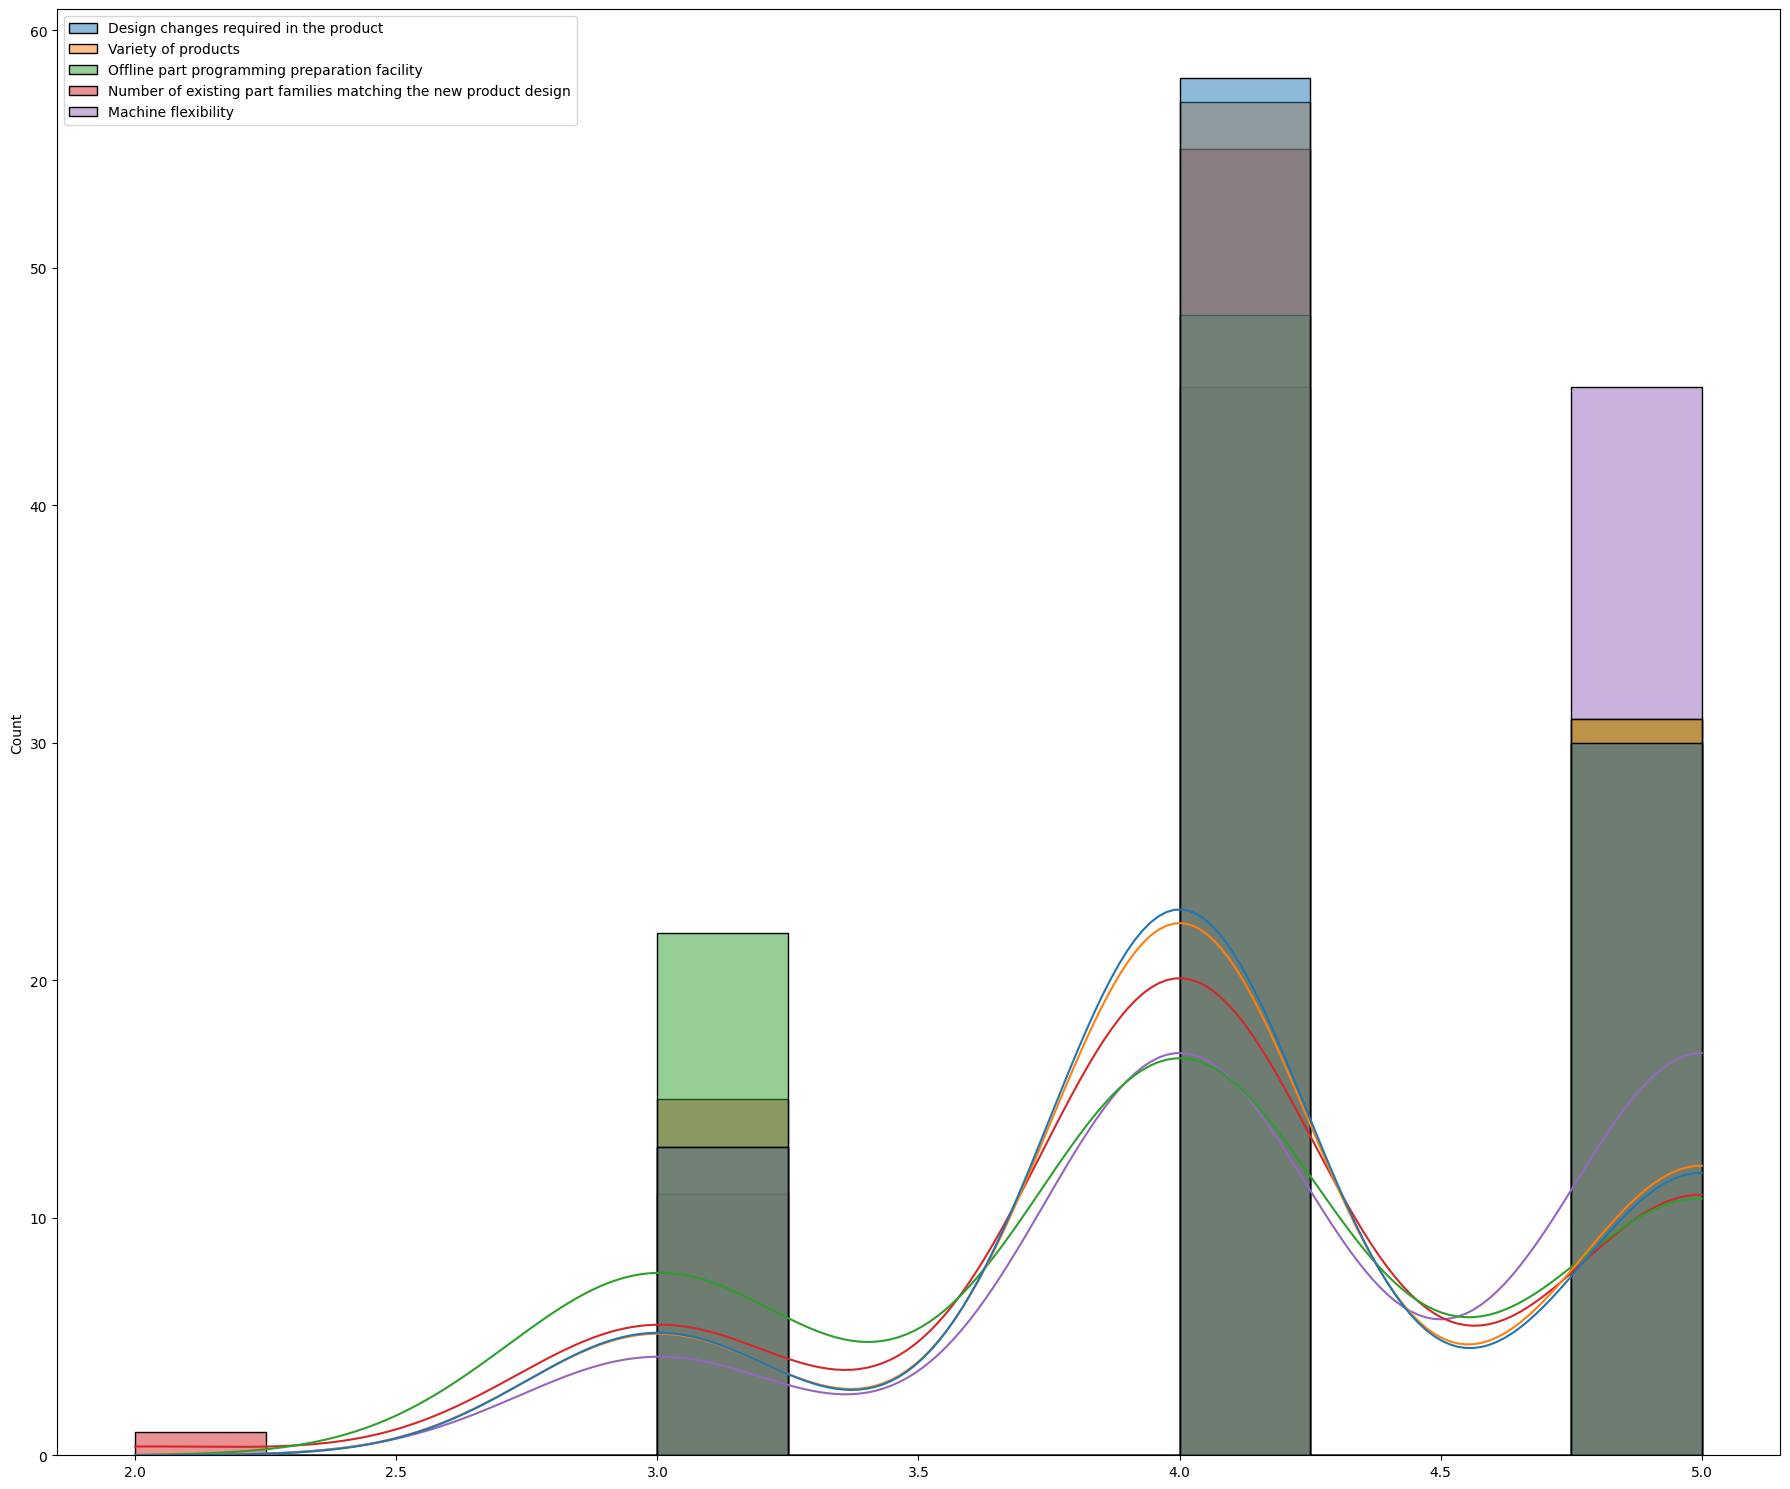

In [16]:
# lokking values with kde ploth a distribution plot

plt.figure(figsize=(18,15),)
sns.histplot(df_v,kde=True)
plt.tight_layout()
plt.show()

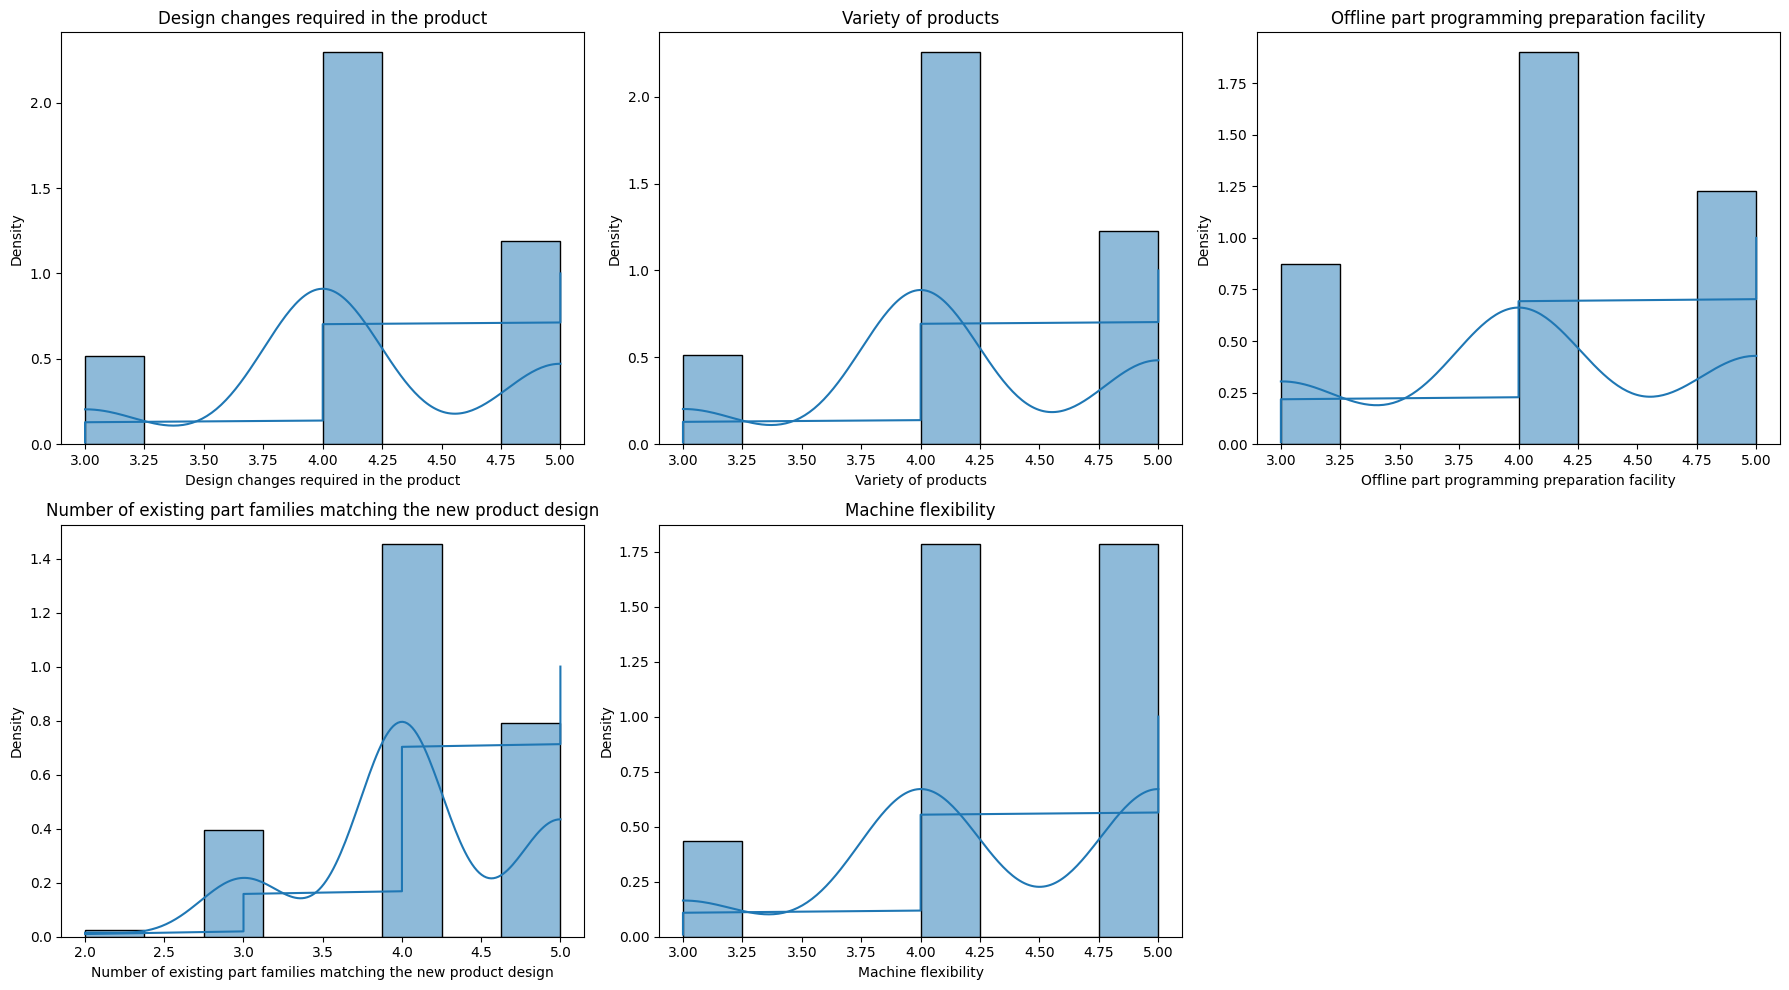

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cols = df_v.select_dtypes(include='float').columns

rows = (len(cols) + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.histplot(
        df_v[col],
        kde=True,
        ax=axes[i],
        stat='density'
    )

    sorted_data = np.sort(df_v[col])
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)

    axes[i].plot(sorted_data, cdf)

    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- this shows most of the features have same distribution if later their score may also be similar they all may play a same roll in flexibility example look at the raw 1

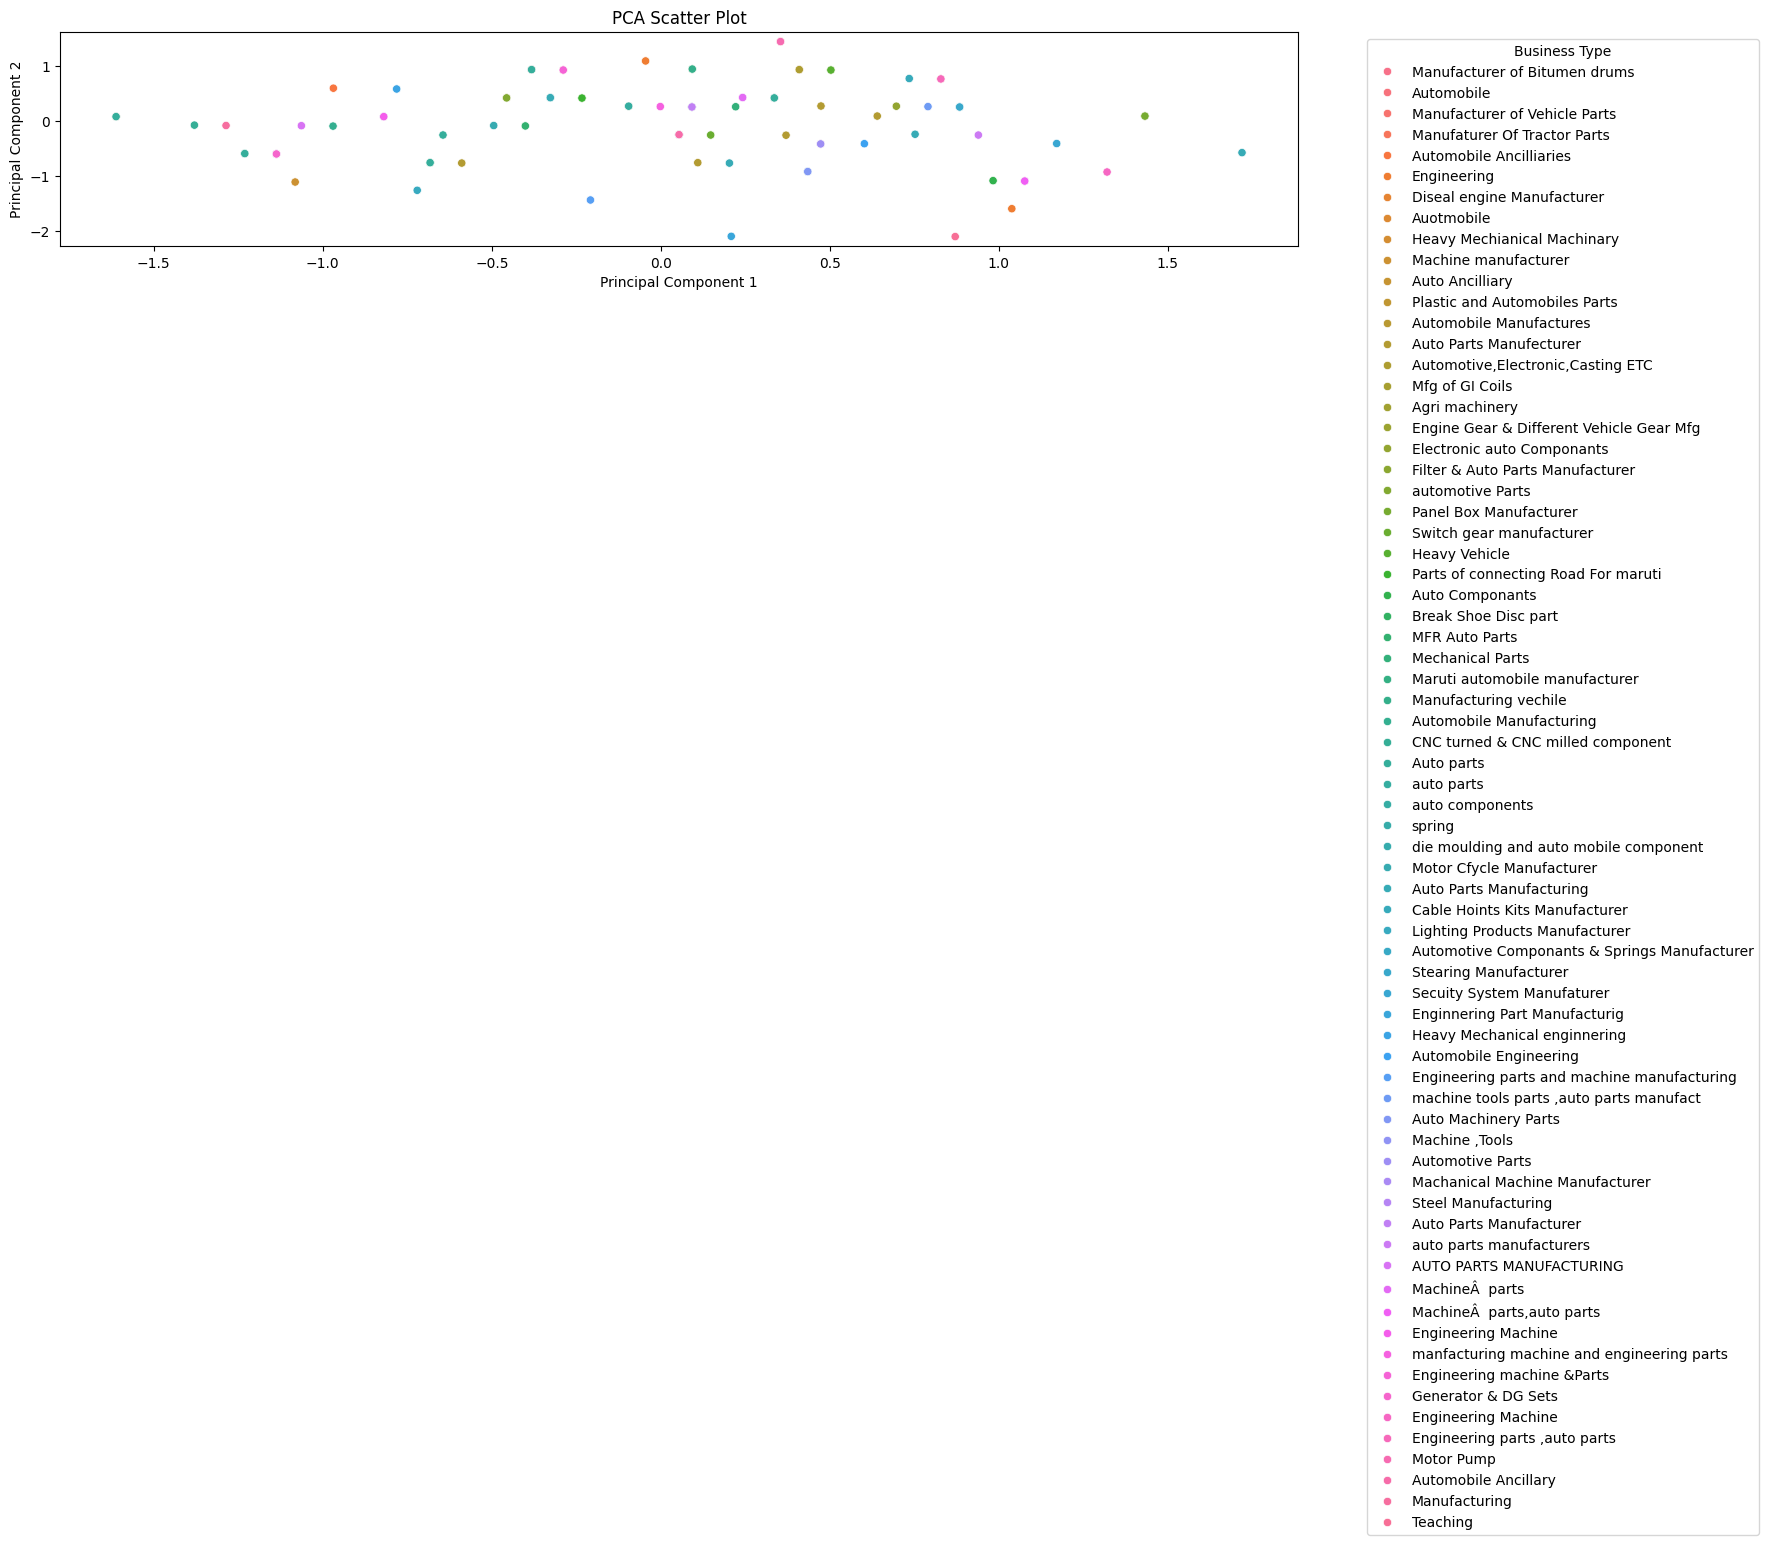

In [18]:
pca = PCA(n_components=2)

extracted = pca.fit_transform(df_v)

plt.figure(figsize=(18, 10))

sns.scatterplot(
    x=extracted[:, 0],
    y=extracted[:, 1],
    hue=df['Type of business']
)

plt.title("PCA Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Legend outside graph
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title='Business Type'
)

plt.tight_layout()
plt.show()

# Conclusion 
we need to consider both distribution using pca and entropy of the column

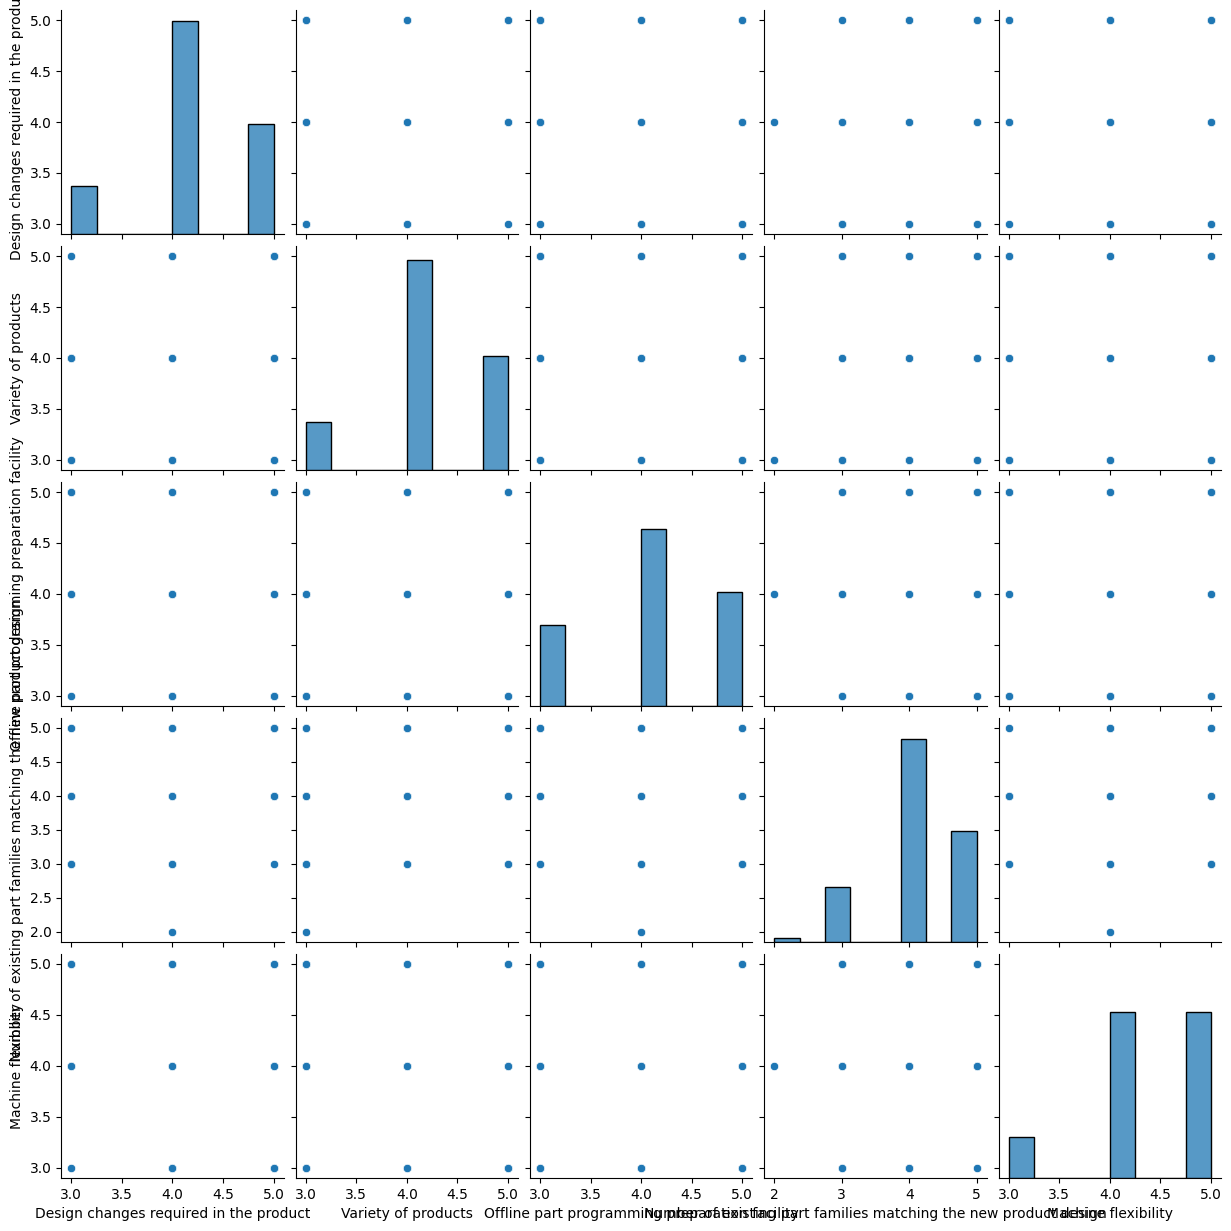

In [19]:
sns.pairplot(df)


# Constructing Algorithm Which can directly rank features

In [20]:
from sklearn.preprocessing import MinMaxScaler

sc=MinMaxScaler()
numerical_df=df.select_dtypes(include=['number'])

scaled_cols=sc.fit_transform(numerical_df)
df[numerical_df.columns]=scaled_cols

In [21]:

!pip install scikit-learn --quiet
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity


def reconstruction_error(X, n_components=1):
    """This first compress and then reproject data to original one"""
    # scaler = MinMaxScaler()
    # X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)

    return np.mean((X - X_reconstructed) ** 2)

def get_pc1(X, n_components=1):
    """The PCA component that one unit vector which has high variance ratio"""
    # scaler = MinMaxScaler()
    # X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=n_components)
    pca.fit(X)

    return pca.components_[0]

def leave_one_out_pca(data_frame: pd.DataFrame, beta=0.7):
    """This First Construct Complete data score then remove a column find out diference and then gives scores"""

    scores = {}

    # -------- FULL DATA BASELINE --------
    E_full = reconstruction_error(data_frame, n_components=1)
    pc1_full = get_pc1(data_frame)

    for col in data_frame.columns:

        print(f"Processing column: {col}")

        df_drop = data_frame.drop(columns=[col])

        if df_drop.shape[1] < 1:
            scores[col] = 0
            continue

        E_i = reconstruction_error(df_drop, n_components=1)

        recon_score = E_i - E_full


        pc1_i = get_pc1(df_drop)

        min_len = min(len(pc1_full), len(pc1_i))
        cos_sim = cosine_similarity(
            pc1_full[:min_len].reshape(1, -1),
            pc1_i[:min_len].reshape(1, -1)
        )[0][0]

        direction_score = 1 - cos_sim


        score = beta * recon_score + (1 - beta) * direction_score

        scores[col] = score

    return scores


# ========================== leave_one_out K-mean ============================================
def plot_kmeans_clusters(X, labels,file_path,score):
    
    # # reducing to 2D
    # pca = PCA(n_components=2)
    # X_2d = pca.fit_transform(X)

    # plt.figure(figsize=(8,6))

    # plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=50)

    # plt.title("KMeans Clusters (PCA Projection)")
    # plt.xlabel("PCA 1")
    # plt.ylabel("PCA 2")
    # plt.text(0.98, 0.98, f"Score: {score}",
    #      transform=plt.gca().transAxes,
    #      fontsize=12,
    #      va='top',
    #      ha='right')
    # # plt.legend()
    # plt.colorbar(label="Cluster")
    # plt.savefig(file_path)
    # plt.close()
    # # plt.show()
    pass

def find_best_k(df, k_range=(2, 10)):
    # X = StandardScaler().fit_transform(df)

    best_k = 2
    best_score = -1

    for k in range(k_range[0], k_range[1] + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(df)

        score = silhouette_score(df, labels)

        if score > best_score:
            best_score = score
            best_k = k

    return best_k

def feature_importance_kmeans(df):
    """if after removing features clusters are not overlaping and clear (high silhouette score) then feature is not important """
    # scaler = StandardScaler()
    # X_scaled_full = scaler.fit_transform(df)

    print("Finding best k")
    best_k=find_best_k(df=df)
    print("found best k ", best_k)
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels_full = kmeans.fit_predict(df)

    base_score = silhouette_score(df, labels_full)

    m = {}

    fig_folder="./output/fig"

    os.makedirs(fig_folder, exist_ok=True)

    for col in df.columns:
        X_drop = df.drop(columns=[col])

        # X_scaled = scaler.fit_transform(X_drop)

        kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_drop)



        score = silhouette_score(X_drop, labels)

        plot_kmeans_clusters(X_drop, labels, os.path.join(fig_folder,f"{col}_Cluster.png"),score=score)

        m[col] = base_score - score

    return m   



# ============================== leave one out dbscan ========================================



def feature_importance_dbscan(df, eps=0.5, min_sample=5):

    fig_folder = "./output/fig"
    os.makedirs(fig_folder, exist_ok=True)

    # -------- Safe Silhouette --------
    def safe_silhouette(X, labels):
        unique = set(labels) - {-1}  # noise removing step

        if len(unique) < 2:
            return 0

        return silhouette_score(X, labels)

    db = DBSCAN(eps=eps, min_samples=min_sample)
    labels_full = db.fit_predict(df)

    base_score = safe_silhouette(df, labels_full)

    m = {}

    for col in df.columns:

        X_drop = df.drop(columns=[col])

        db = DBSCAN(eps=eps, min_samples=min_sample)
        labels = db.fit_predict(X_drop)

        score = safe_silhouette(X_drop, labels)

        plot_kmeans_clusters(
            X_drop,
            labels,
            os.path.join(fig_folder, f"{col}_Cluster.png"),
            score=score
        )

        m[col] = base_score - score

    return m


# ========================== Entropy Score =========================================
def entropy_calculation(data_frame: pd.DataFrame):
    """calculates entropy of the column if 
    col have only 55555 values its entropy should be low because doesn't give information whereas 23454 will bhi high
    """

    m = {}

    for col in data_frame.columns:

        print(f"Processing column: {col}")

        value_counts = data_frame[col].value_counts(normalize=True) # normalised True will give probability

        entropy = -(value_counts * np.log2(value_counts)).sum()

        m[col] = entropy

    return m

# leave_one_out_pca or k-mean or db scan with sihorate will first calculate score for complete dataset then it drops one column at a time and if there is a drastic change in the column the colum is important
alpha parameter desids the how must priority to give to leave_one_out and entropym

In [22]:
leave_one_out_pca(df.drop(columns=df.columns[:2]))

Processing column: Design changes required in the product
Processing column: Variety of products
Processing column: Offline part programming preparation facility
Processing column: Number of existing part families matching the new product design
Processing column: Machine flexibility


{'Design changes required in the product': np.float64(0.2825278945423327),
 'Variety of products': np.float64(0.2080674439655786),
 'Offline part programming preparation facility': np.float64(0.2891730274770088),
 'Number of existing part families matching the new product design': np.float64(0.0053794490089353435),
 'Machine flexibility': np.float64(-0.006966549746105156)}

In [23]:
entropy_calculation(df.drop(columns=df.columns[:2]))

Processing column: Design changes required in the product
Processing column: Variety of products
Processing column: Offline part programming preparation facility
Processing column: Number of existing part families matching the new product design
Processing column: Machine flexibility


{'Design changes required in the product': np.float64(1.3604359191726965),
 'Variety of products': np.float64(1.3694933365615216),
 'Offline part programming preparation facility': np.float64(1.5120156286267532),
 'Number of existing part families matching the new product design': np.float64(1.4722227595216997),
 'Machine flexibility': np.float64(1.3877112206262405)}

In [24]:

from typing import Literal
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

def ratio(x):
    return x/x.sum()


def normalise(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))



# ===================== aplies above scoring concepts in single function ================================
def feature_score(dataframe:pd.DataFrame,alpha:float,beta:float,eps=0.5,min_sample=5,kind:Literal['k-mean','dbscan','pca']='pca'):
    df=dataframe.copy()

    if kind=='dbscan':
        pca_score=feature_importance_dbscan(df=df,eps=0.5,min_sample=5)
    elif kind== 'pca':
        pca_score=leave_one_out_pca(df,beta)
    elif kind=='k-mean':
        pca_score=feature_importance_kmeans(df=df)    
    df=dataframe.copy()
    ent_score=entropy_calculation(data_frame=df)

    features = list(dataframe.columns)

    pca_score = np.array([pca_score[f] for f in features])
    ent_score = np.array([ent_score[f] for f in features])

    features_weightage=alpha*pca_score+(1-alpha)*ent_score

    features_weightage_prob=softmax(features_weightage)
    # features_weightage=ratio(features_weightage)
    # features_weightage=normalise(features_weightage)

    return {k: v for k, v in zip(dataframe.columns, features_weightage)},{k: v for k, v in zip(dataframe.columns, features_weightage_prob)}


    


In [25]:
feature_score(df.drop(columns=df.columns[:2]), alpha=0.5,beta=0.7)

Processing column: Design changes required in the product
Processing column: Variety of products
Processing column: Offline part programming preparation facility
Processing column: Number of existing part families matching the new product design
Processing column: Machine flexibility
Processing column: Design changes required in the product
Processing column: Variety of products
Processing column: Offline part programming preparation facility
Processing column: Number of existing part families matching the new product design
Processing column: Machine flexibility


({'Design changes required in the product': np.float64(0.8214819068575145),
  'Variety of products': np.float64(0.7887803902635501),
  'Offline part programming preparation facility': np.float64(0.900594328051881),
  'Number of existing part families matching the new product design': np.float64(0.7388011042653175),
  'Machine flexibility': np.float64(0.6903723354400677)},
 {'Design changes required in the product': np.float64(0.20627403015943566),
  'Variety of products': np.float64(0.19963765765690666),
  'Offline part programming preparation facility': np.float64(0.22325574423606112),
  'Number of existing part families matching the new product design': np.float64(0.18990514785647722),
  'Machine flexibility': np.float64(0.18092742009111926)})

In [26]:
# Complete workflow
!pip install openpyxl --quiet
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os
from dataclasses import dataclass

@dataclass
class Config:
    data_file_path:str=""
    kind:Literal['k-mean','dbscan','pca']='pca'
    alpha:float=0.5
    beta:float=0.7
    eps:float=0.5,
    min_sample:int=5
    file_save_path:str="./output/feature_scores.xlsx"


def extract_relevant_features_with_scores(
    data_file_path: str,
    kind:Literal['k-mean','dbscan','pca']='pca',

    alpha: float = 0.5,
    beta:float=0.5,
    eps:float=0.5,
    min_sample:int=5,
    file_save_path:str="./output/feature_scores.xlsx"
):

    # ================= preprocessing df for proper formate =================
    print(f"Loading data from {data_file_path} and preprocessing...")
    df = pd.read_csv(
        data_file_path
    )

    print("Normalising data")
    numeric_df = df.select_dtypes(include=['number'])

    sc = MinMaxScaler()
    scaled = sc.fit_transform(numeric_df)

    df[numeric_df.columns] = scaled
    df[numeric_df.columns]=np.log1p(scaled)

    

    # df=pd.concat()


    # ============= Handling missing values =============
    print("Handling missing values by forward filling...")
    # amf.ffill(inplace=True)
    df.dropna(inplace=True)
    
    print("Missing values after handling:")


    # ============= Calculating feature scores =============
    print("Calculating feature scores...")
    apf_feature_score,apf_feature_score_norm=feature_score(df.drop(columns=df.columns[:2]), alpha=alpha,beta=beta,eps=eps,min_sample=min_sample,kind=kind)
    

    # # ============= Calculating header scores =============
    # print("Calculating header scores...")
    # header_scores=header_score([amf, arf, apf])


    # # ============= Calculating final feature rank =============
    # print("Calculating final feature rank...")
    # final_feature_rank=full_feature_rank(
    #     [amf_feature_score,
    #      arf_feature_score,
    #      apf_feature_score],
    #     header_scores
    # )


    # ============= Sorting final feature rank and saving to dataframe =============
    print("Sorting final feature rank...")
    final_feature_rank = dict(sorted(apf_feature_score.items(), key=lambda item: item[1], reverse=True))
    final_feature_rank_norm = dict(sorted(apf_feature_score_norm.items(), key=lambda item: item[1], reverse=True))


    # ============== Creating DataFrame to save =============
    print("Creating final data DataFrame...")
    final_data_to_save=pd.DataFrame({
    "Feature": [x.split("_ ")[1] for x in list(final_feature_rank.keys())],
    "Score": list(final_feature_rank.values()),
    "Softmax": list(final_feature_rank_norm.values()),
    "Rank": np.arange(1,len(final_feature_rank)+1)
    })


    # ============== Saving to excel =============
    print("Saving to CSV...")
    os.makedirs(os.path.dirname(file_save_path), exist_ok=True)

    final_data_to_save.to_csv(file_save_path,index=False)

    return final_data_to_save
    # with pd.ExcelWriter(file_save_path) as writer:
    #     final_data_to_save.to_excel(writer, sheet_name="Final Feature Rank", index=False)
    #     amf_final_features_to_save.to_excel(writer, sheet_name="AMF Feature Scores", index=False)
    #     arf_final_features_to_save.to_excel(writer, sheet_name="ARF Feature Scores", index=False)
    #     apf_final_features_to_save.to_excel(writer, sheet_name="APF Feature Scores", index=False)
    #     header_final_score_to_save.to_excel(writer,sheet_name="Headers Score",index=False)


        

     

In [27]:
f_df=extract_relevant_features_with_scores("data/survey1_apf.csv", kind='pca',alpha=0.5,beta=0.7,eps=0.5,min_sample=5,file_save_path="./output/apf_feature_scores.csv")



Loading data from data/survey1_apf.csv and preprocessing...
Normalising data
Handling missing values by forward filling...
Missing values after handling:
Calculating feature scores...
Processing column: APF_ Design changes required in the product
Processing column: APF_ Variety of products
Processing column: APF_ Offline part programming preparation facility
Processing column: APF_ Number of existing part families matching the new product design
Processing column: APF_ Machine flexibility
Processing column: APF_ Design changes required in the product
Processing column: APF_ Variety of products
Processing column: APF_ Offline part programming preparation facility
Processing column: APF_ Number of existing part families matching the new product design
Processing column: APF_ Machine flexibility
Sorting final feature rank...
Creating final data DataFrame...
Saving to CSV...


In [28]:
f_df

,Feature,Score,Softmax,Rank
0,Machine flexibility,0.879563,0.210371,1
1,Offline part programming preparation facility,0.856721,0.205620,2
2,Number of existing part families matching the ...,0.836753,0.201555,3
3,Variety of products,0.785333,0.191453,4
4,Design changes required in the product,0.782979,0.191002,5


In [29]:
# hybrid score

import pandas as pd


# RRF reranking
def update_weights(method_results: dict, k=60):
    """
    This method uses reciprocal rank fusion
    """

    final_scores = {}

    for method_name, (df, weight) in method_results.items():

        for _, row in df.iterrows():

            feature = row['Feature']
            rank = row['Rank']

            # Weighted Reciprocal Rank Fusion
            rrf_score = weight / (k + rank)

            # Updating feature score using rrf_score
            hybrid_score = rrf_score * row['Score']

            final_scores[feature] = final_scores.get(feature,0)+hybrid_score

    final_df = pd.DataFrame({
        "Feature": final_scores.keys(),
        "HybridScore": final_scores.values()
    })

    final_df = final_df.sort_values(
        by="HybridScore",
        ascending=False
    ).reset_index(drop=True)

    final_df['FinalRank'] = final_df.index + 1

    return final_df


def hybrid_(*args):

    methods = ['pca', 'k-mean', 'dbscan']

    weights = {
        'k-mean': 0.3,
        'dbscan': 0.2,
                'pca': 0.5
    }

    m = {}

    for method in methods:

        f_df = extract_relevant_features_with_scores(
            "data/survey1_apf.csv",
            kind=method,
            alpha=0.5,
            beta=0.7,
            eps=0.5,
            min_sample=5,
            file_save_path="./output/apf_feature_scores.csv"
        )
        print(method)

        m[method] = (f_df, weights[method])

    return update_weights(m)

In [30]:
hybrid_()

Loading data from data/survey1_apf.csv and preprocessing...
Normalising data
Handling missing values by forward filling...
Missing values after handling:
Calculating feature scores...
Processing column: APF_ Design changes required in the product
Processing column: APF_ Variety of products
Processing column: APF_ Offline part programming preparation facility
Processing column: APF_ Number of existing part families matching the new product design
Processing column: APF_ Machine flexibility
Processing column: APF_ Design changes required in the product
Processing column: APF_ Variety of products
Processing column: APF_ Offline part programming preparation facility
Processing column: APF_ Number of existing part families matching the new product design
Processing column: APF_ Machine flexibility
Sorting final feature rank...
Creating final data DataFrame...
Saving to CSV...
pca
Loading data from data/survey1_apf.csv and preprocessing...
Normalising data
Handling missing values by forward 

,Feature,HybridScore,FinalRank
0,Machine flexibility,0.013674,1
1,Offline part programming preparation facility,0.012948,2
2,Number of existing part families matching the ...,0.012431,3
3,Variety of products,0.011269,4
4,Design changes required in the product,0.011176,5


In [31]:
# plt.figure(figsize=(8, 8))

# plt.pie(
#     f_df['Score'],              
#     labels=f_df['Feature'],    
#     autopct='%1.1f%%'
# )

# plt.title("Feature Importance Pie Chart")

# plt.show()